# Customer Segmentation Analysis using K-Means Clustering

## Objective
Segment customers using RFM analysis and K-Means clustering to support targeted marketing strategies.

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline




## Load the Dataset

In [14]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\hp\Documents\Oasis Infobyte Tasks or Projects Documents\Task 2\Task 2 Documents\extracted csv\OnlineRetail.csv",
    encoding="ISO-8859-1"
)

## Initial Data Exploration

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [19]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [20]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (541909, 8)


In [21]:
# Column names
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [22]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## Descriptive Statistics

In [23]:
# Summary statistics
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Cleaning and Preprocessing

In [24]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [27]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [28]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [29]:
# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5225


In [30]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (401604, 8)


In [31]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [32]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [33]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [34]:
df = df[df['Quantity'] > 0]

In [36]:
df = df[df['UnitPrice'] > 0]

In [37]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [38]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [41]:
# Average Purchase Value
average_purchase_value = df["TotalAmount"].mean()

print("Average Purchase Value:", round(average_purchase_value,2))

Average Purchase Value: 22.63


In [42]:
# Purchase Frequency

purchase_frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()

print(purchase_frequency.head())

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64


In [43]:
# Customer Lifetime Value

customer_clv = df.groupby("CustomerID")["TotalAmount"].sum()

print(customer_clv.head())

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: TotalAmount, dtype: float64


## RFM Feature Engineering

In [44]:
# Latest date in dataset

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [45]:
# Create RFM Table

rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    "InvoiceNo":"nunique",

    "TotalAmount":"sum"

})

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [46]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


## Data Standardization

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled

array([[ 2.33457414e+00, -4.25096503e-01,  8.36301037e+00],
       [-9.05340320e-01,  3.54416797e-01,  2.51698905e-01],
       [-1.75359593e-01, -3.53398530e-02, -2.79878269e-02],
       ...,
       [-8.45341904e-01, -2.95177619e-01, -2.08214334e-01],
       [-8.85340848e-01,  1.52368675e+00, -3.51515172e-04],
       [-4.95351144e-01, -1.65258736e-01, -2.35311112e-02]],
      shape=(4338, 3))

## Determine the Optimal Number of Clusters

## Apply K-Means Clustering

In [48]:
from sklearn.cluster import KMeans

wcss=[]

for i in range(1,11):

    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

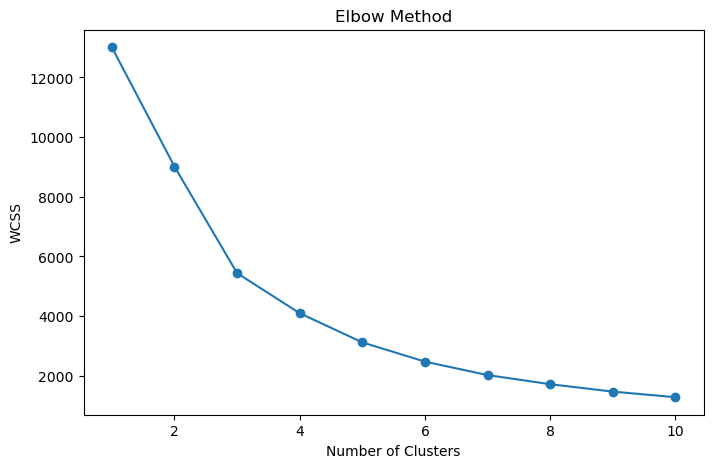

In [49]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [50]:
# Apply K-Means with K = 3

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


In [51]:
# Customers in each cluster

print(rfm["Cluster"].value_counts())

Cluster
1    3230
0    1082
2      26
Name: count, dtype: int64


In [52]:
# Mean values of each cluster

cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,247.106285,1.582255,629.663689
1,41.454180,4.672755,1849.670202
2,6.038462,66.423077,85826.078077


## Cluster Visualization

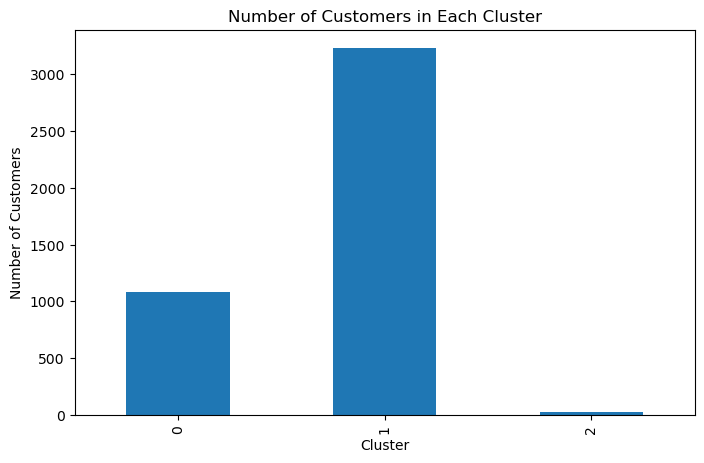

In [53]:
plt.figure(figsize=(8,5))

rfm["Cluster"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

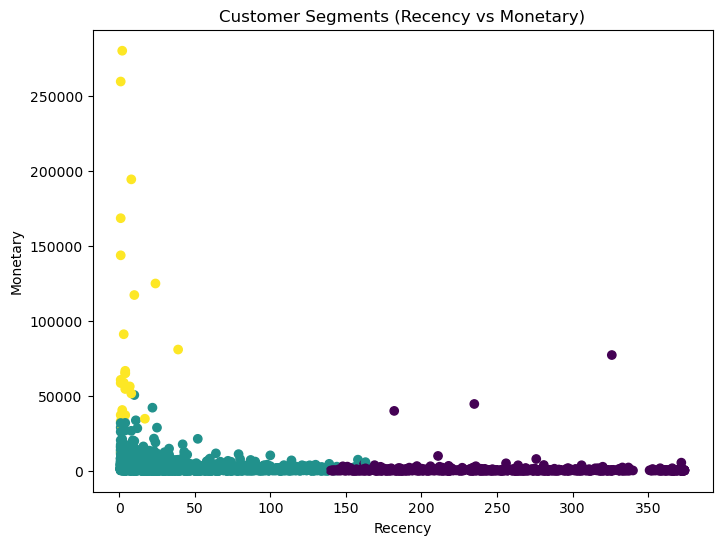

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Recency")

plt.ylabel("Monetary")

plt.title("Customer Segments (Recency vs Monetary)")

plt.show()

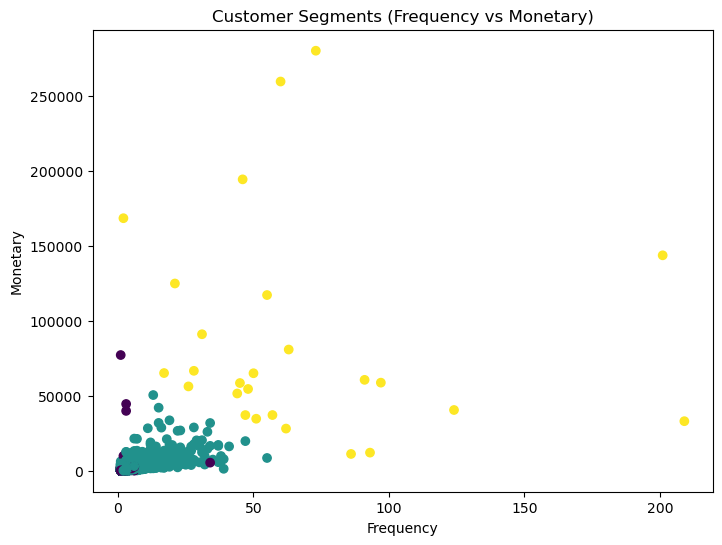

In [56]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")

plt.ylabel("Monetary")

plt.title("Customer Segments (Frequency vs Monetary)")

plt.show()

## Cluster Profiling

In [57]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,247.106285,1.582255,629.663689
1,41.454180,4.672755,1849.670202
2,6.038462,66.423077,85826.078077


Marketing Insights

Cluster 0:
Customers in this segment have moderate purchase frequency and spending. They should be targeted with personalized offers and loyalty rewards to increase repeat purchases.

Cluster 1:
These customers are less active and spend relatively less. Promotional discounts, email campaigns, and re-engagement offers can encourage them to purchase again.

Cluster 2:
These are the most valuable customers with high purchase frequency and high spending. They should receive exclusive benefits, premium services, and VIP loyalty programs to retain them.

Conclusion

This project successfully segmented e-commerce customers using RFM analysis and the K-Means clustering algorithm. After cleaning and preprocessing the data, customer behavior was analyzed based on Recency, Frequency, and Monetary (RFM) values. The Elbow Method indicated that three clusters were appropriate for segmentation.

The analysis identified three customer groups:

• Cluster 0: Inactive or low-value customers who require re-engagement strategies.
• Cluster 1: Regular and loyal customers who should be retained through personalized offers and loyalty programs.
• Cluster 2: High-value VIP customers who contribute the most revenue and should receive premium services and exclusive rewards.

These insights can help businesses develop targeted marketing strategies, improve customer retention, increase customer lifetime value, and optimize overall business performance.